In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 

In [53]:
df = pd.read_csv(r"C:\Users\User\Recess Term\Gihozo_Patrick\Machine learning\customer_churn.csv")
df.isnull().sum()
df.describe()
df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<Axes: xlabel='Churn'>

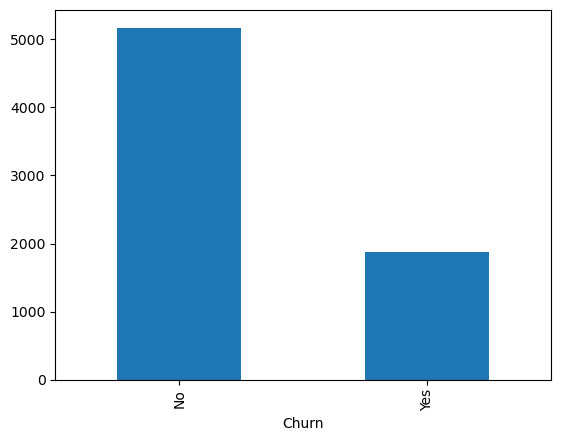

In [54]:
df["Churn"].value_counts().plot(kind="bar")

<Axes: xlabel='Churn', ylabel='count'>

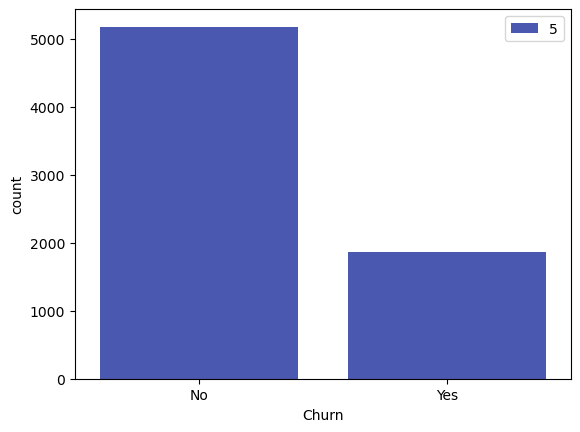

In [55]:
sns.countplot(x='Churn',hue=5,data=df, palette='coolwarm')

In [56]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())
df['TotalCharges'].isnull().sum()

np.int64(0)

In [57]:
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns

print("Numerical columns:", list(numeric_cols))
print("Categorical columns:", list(categorical_cols))

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [58]:
from sklearn.preprocessing import LabelEncoder as le
categorical_columns =['gender','Partner','InternetService','MultipleLines','OnlineSecurity','PaymentMethod','Dependents','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PhoneService']

for col in categorical_columns:
    df[col]=le().fit_transform(df[col])

In [59]:
from sklearn.model_selection import train_test_split

x = df.drop(['customerID','Churn'],axis =1)
y = df['Churn']
X_train,X_test,y_train,y_test =train_test_split(x,y,test_size =0.2,random_state =0)
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [61]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [63]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 78.21%
